# Sales Analysis Project

## Objective
This project aims to analyze global chocolate sales data to:
- Identify sales trends over time
- Determine top-performing products and regions
- Evaluate salesperson performance
- Analyze revenue efficiency
- Provide actionable business insights

In [1]:
import pandas as pd

df = pd.read_csv("Chocolate Sales (2).csv")
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,4/1/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,1/8/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,7/7/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


In [5]:
df.info()
df.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Sales Person   3282 non-null   object
 1   Country        3282 non-null   object
 2   Product        3282 non-null   object
 3   Date           3282 non-null   object
 4   Amount         3282 non-null   object
 5   Boxes Shipped  3282 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 154.0+ KB


(3282, 6)

In [6]:
df.isnull().sum()

Sales Person     0
Country          0
Product          0
Date             0
Amount           0
Boxes Shipped    0
dtype: int64

In [11]:
df['Amount'] = df['Amount'].replace(r'[\$,]', '', regex=True).astype(float)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.drop_duplicates()

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3282 entries, 0 to 3281
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Sales Person   3282 non-null   object        
 1   Country        3282 non-null   object        
 2   Product        3282 non-null   object        
 3   Date           3282 non-null   datetime64[ns]
 4   Amount         3282 non-null   float64       
 5   Boxes Shipped  3282 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 154.0+ KB


In [13]:
df['Amount'].head()

0     5320.0
1     7896.0
2     4501.0
3    12726.0
4    13685.0
Name: Amount, dtype: float64

In [14]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped,Year,Month,Day
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5320.0,180,2022,1,4
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,7896.0,94,2022,8,1
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,4501.0,91,2022,7,7
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,12726.0,342,2022,4,27
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,13685.0,184,2022,2,24


In [42]:
df['Amount'].sum()

np.float64(19791571.860000003)

In [15]:
monthly_sales = df.groupby('Month')['Amount'].sum().sort_index()

monthly_sales


Month
1    2868712.59
2    2232096.90
3    2404769.29
4    2161927.22
5    2415750.57
6    2773931.94
7    2567532.29
8    2366851.06
Name: Amount, dtype: float64

In [16]:
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%B')

In [23]:
df.groupby('Month_Name')['Amount'].sum().sort_values(ascending=False)

Month_Name
January     2868712.59
June        2773931.94
July        2567532.29
May         2415750.57
March       2404769.29
August      2366851.06
February    2232096.90
April       2161927.22
Name: Amount, dtype: float64

In [22]:
monthly_sales = df.groupby(['Month','Month_Name'])['Amount'].sum().reset_index()

monthly_sales = monthly_sales.sort_values('Month')
monthly_sales

,Month,Month_Name,Amount
0,1,January,2868712.59
1,2,February,2232096.90
2,3,March,2404769.29
3,4,April,2161927.22
4,5,May,2415750.57
5,6,June,2773931.94
6,7,July,2567532.29
7,8,August,2366851.06


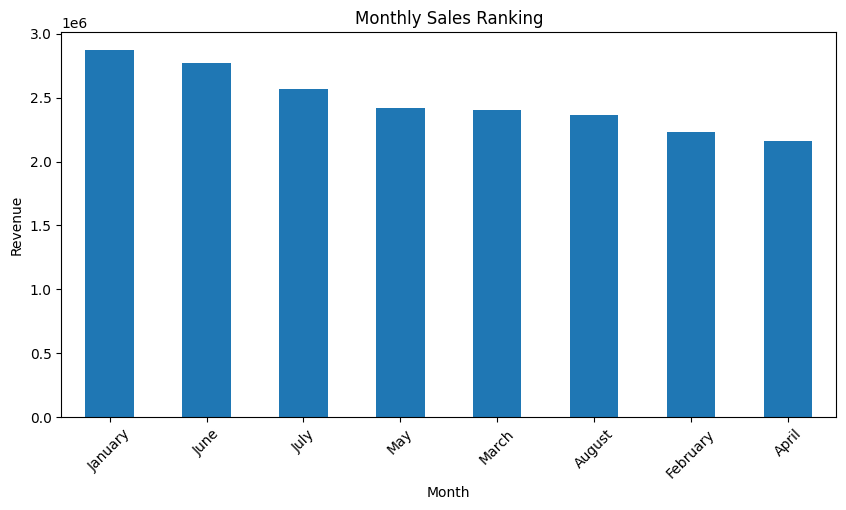

In [39]:
import matplotlib.pyplot as plt

# Step 1: Create ranking
monthly_rank = df.groupby('Month_Name')['Amount'].sum().sort_values(ascending=False)

# Step 2: Plot
plt.figure(figsize=(10,5))
monthly_rank.plot(kind='bar')

plt.title("Monthly Sales Ranking")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)


plt.show()

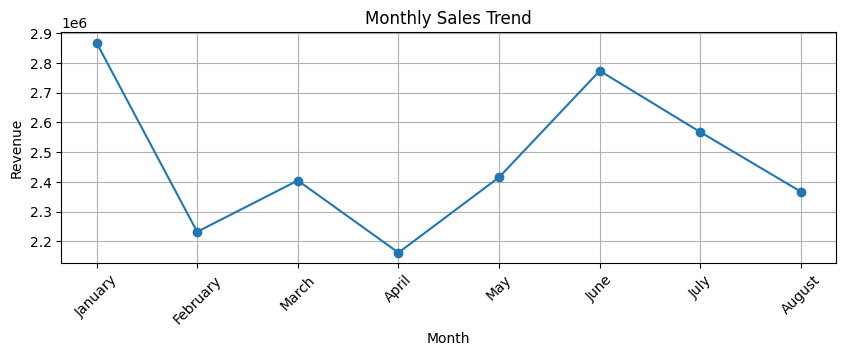

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,3))

plt.plot(monthly_sales['Month_Name'], monthly_sales['Amount'], marker='o')

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.grid()

plt.show()

### Monthly Sales Analysis

Sales performance exhibits a fluctuating pattern throughout the year. Revenue peaks in January at approximately 2.87M, followed by a decline reaching its lowest point in April at 2.16M. A recovery phase is observed from May through July, with June recording the second-highest sales.

This pattern suggests a cyclical trend, with strong early-year performance, a mid-quarter slowdown, and a subsequent rebound. The decline between February and April may indicate reduced demand or operational inefficiencies, while the recovery phase suggests improved sales activity or effective business strategies during mid-year.

In [49]:
df.groupby('Country')['Amount'].sum().sort_values(ascending=False)

Country
Australia      3646444.35
UK             3365388.90
India          3343730.83
USA            3313858.09
Canada         3078495.65
New Zealand    3043654.04
Name: Amount, dtype: float64

In [81]:
country_sales_df = (
    df.groupby('Country')['Amount']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

country_sales_df

,Country,Amount
0,Australia,3646444.35
1,UK,3365388.90
2,India,3343730.83
3,USA,3313858.09
4,Canada,3078495.65
5,New Zealand,3043654.04


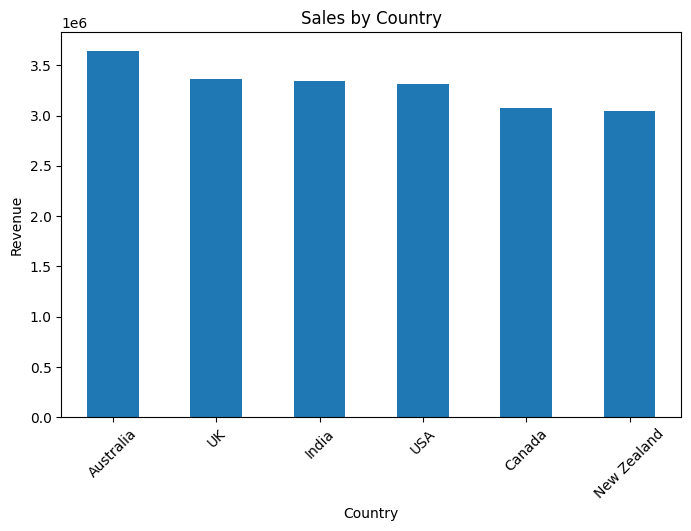

In [51]:
country_sales = df.groupby('Country')['Amount'].sum().sort_values(ascending=False)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
country_sales.plot(kind='bar')

plt.title("Sales by Country")
plt.xlabel("Country")
plt.ylabel("Revenue")


plt.xticks(rotation=45)
plt.show()

In [44]:
df.groupby('Product')['Amount'].sum().sort_values(ascending=False)

Product
Smooth Sliky Salty      1120201.09
50% Dark Bites          1087659.35
White Choc              1054257.00
Peanut Butter Cubes     1036591.09
Eclairs                  996947.96
99% Dark & Pure          960033.45
85% Dark Bars            955268.24
Organic Choco Syrup      945345.73
Spicy Special Slims      938131.69
Mint Chip Choco          904989.55
Almond Choco             890454.65
Manuka Honey Choco       885208.03
Milk Bars                866273.62
Raspberry Choco          845388.41
After Nines              837215.67
Fruit & Nut Bars         829278.96
Orange Choco             824070.85
Drinking Coco            822245.57
Baker's Choco Chips      799085.67
Choco Coated Almonds     773062.91
Caramel Stuffed Bars     742516.15
70% Dark Bites           677346.22
Name: Amount, dtype: float64

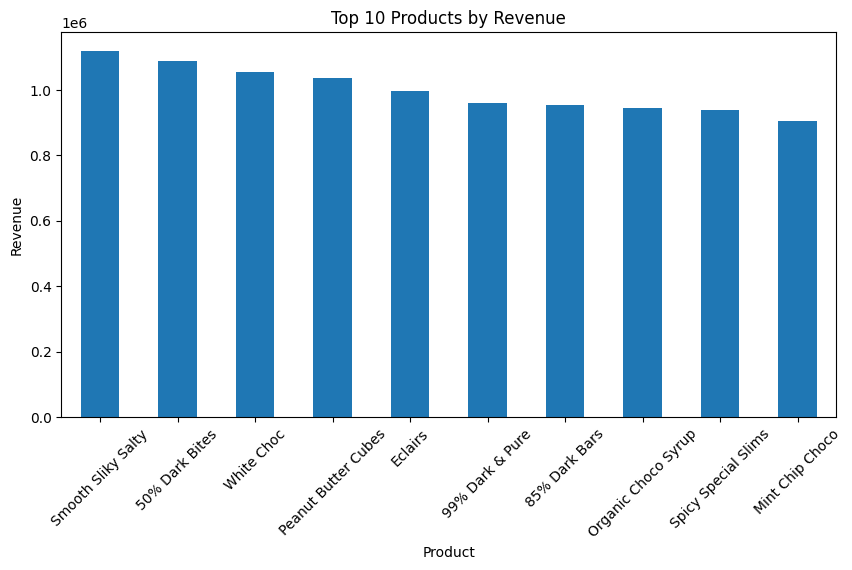

In [52]:
top_products = df.groupby('Product')['Amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_products.plot(kind='bar')

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")


plt.xticks(rotation=45)
plt.show()

In [45]:
df.groupby('Sales Person')['Amount'].sum().sort_values(ascending=False)

Sales Person
Ches Bonnell           1022599.96
Oby Sorrel             1017204.12
Madelene Upcott        1010028.72
Kelci Walkden          1002929.10
Brien Boise             997326.48
Van Tuxwell             974425.09
Dennison Crosswaite     931849.57
Beverie Moffet          892421.37
Kaine Padly             849062.76
Marney O'Breen          836427.63
Barr Faughny            830826.91
Roddy Speechley         808359.58
Gunar Cockshoot         762283.43
Gigi Bohling            742296.51
Karlen McCaffrey        713832.64
Jehu Rudeforth          708505.03
Jan Morforth            706585.50
Curtice Advani          691797.92
Rafaelita Blaksland     668865.45
Husein Augar            656149.73
Andria Kimpton          648214.81
Mallorie Waber          642903.33
Camilla Castle          628613.13
Dotty Strutley          608101.17
Wilone O'Kielt          439961.92
Name: Amount, dtype: float64

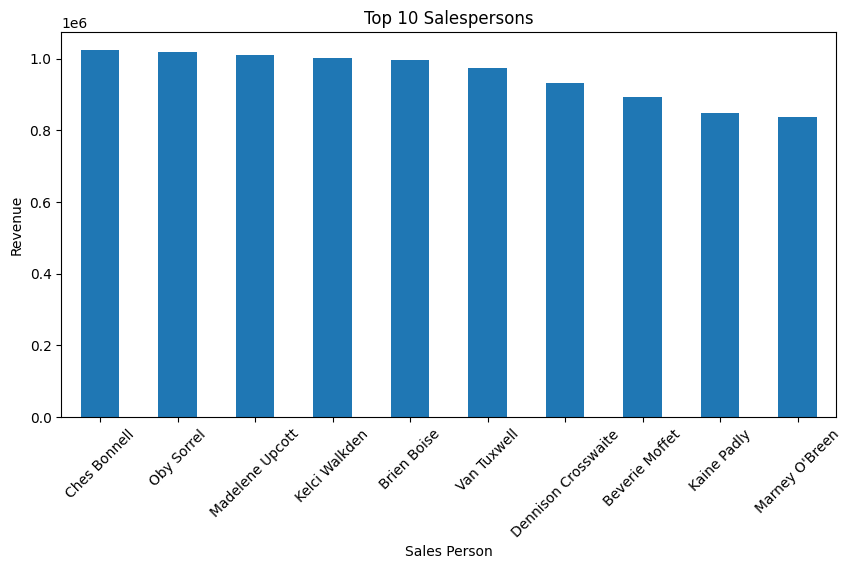

In [54]:
top_salespeople = df.groupby('Sales Person')['Amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_salespeople.plot(kind='bar')

plt.title("Top 10 Salespersons")
plt.xlabel("Sales Person")
plt.ylabel("Revenue")



plt.xticks(rotation=45)
plt.show()

In [46]:
df['Revenue_per_Box'] = df['Amount'] / df['Boxes Shipped']

df.groupby('Product')['Revenue_per_Box'].mean().sort_values(ascending=False)

Product
White Choc              246.487640
Mint Chip Choco         169.830736
99% Dark & Pure         155.224428
Choco Coated Almonds    127.188276
Orange Choco            126.969960
Spicy Special Slims     126.797867
Eclairs                 124.347012
50% Dark Bites          117.096311
Fruit & Nut Bars        113.930505
85% Dark Bars           109.348544
Peanut Butter Cubes      96.841860
Organic Choco Syrup      96.722694
Baker's Choco Chips      95.031763
Raspberry Choco          94.285965
Smooth Sliky Salty       92.188668
Milk Bars                86.133565
Manuka Honey Choco       83.109610
Almond Choco             78.719987
Caramel Stuffed Bars     77.783663
After Nines              77.664147
Drinking Coco            65.306225
70% Dark Bites           61.329081
Name: Revenue_per_Box, dtype: float64

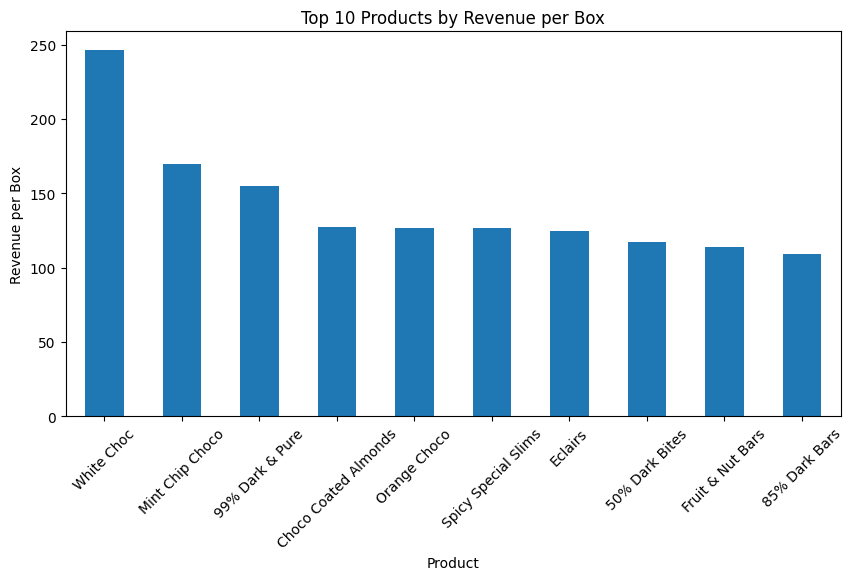

In [56]:
efficiency = df.groupby('Product')['Revenue_per_Box'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
efficiency.plot(kind='bar')

plt.title("Top 10 Products by Revenue per Box")
plt.xlabel("Product")
plt.ylabel("Revenue per Box")


plt.xticks(rotation=45)
plt.show()

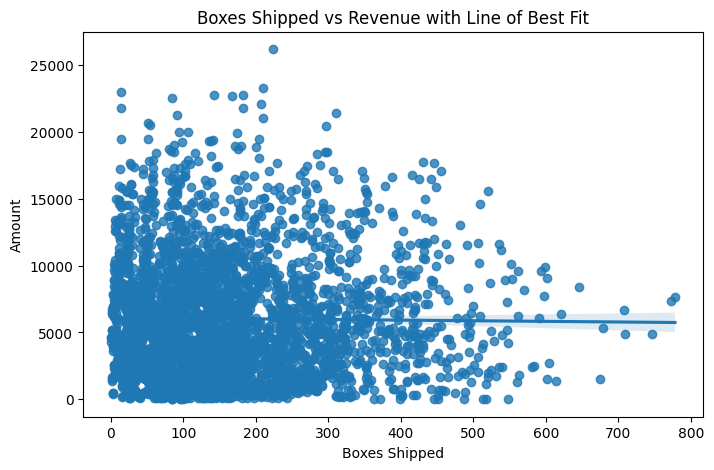

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.regplot(data=df, x='Boxes Shipped', y='Amount')

plt.title("Boxes Shipped vs Revenue with Line of Best Fit")
plt.show()

In [64]:
from sklearn.linear_model import LinearRegression

# Define variables
X = df[['Boxes Shipped']]
y = df['Amount']

# Train model
model = LinearRegression()
model.fit(X, y)

# Extract coefficients
slope = model.coef_[0]
intercept = model.intercept_

print(f"Equation: Revenue = {slope:.2f} * Boxes Shipped + {intercept:.2f}")

Equation: Revenue = -0.47 * Boxes Shipped + 6107.08


In [62]:
from sklearn.metrics import r2_score

y_pred = model.predict(X)

print("R² Score:", r2_score(y, y_pred))

R² Score: 0.00017302425149179346


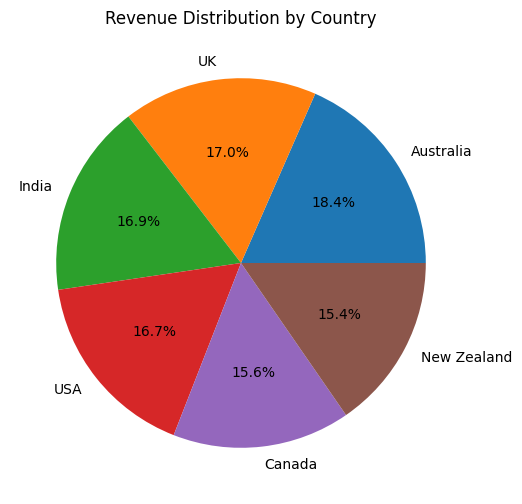

In [58]:
country_sales.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6))

plt.title("Revenue Distribution by Country")
plt.ylabel('')
plt.show()

# Sales Analysis Report Summary

## 1. Objective  
The objective of this analysis was to evaluate sales performance across multiple dimensions—time, geography, product portfolio, and sales personnel—in order to identify key revenue drivers, operational patterns, and opportunities for optimization.

---

## 2. Dataset Overview  
The dataset consists of 3,282 records covering sales transactions across multiple countries, products, and sales representatives within a single year (2022). Key variables include:

- Sales Person  
- Country  
- Product  
- Date  
- Amount (Revenue)  
- Boxes Shipped (Volume)  

---

## 3. Key Findings  

### 3.1 Sales Trend (Time Analysis)  
Sales exhibit a fluctuating pattern throughout the year:

- Peak performance in January (approximately 2.87M)  
- Decline from February to April (lowest in April at approximately 2.16M)  
- Recovery from May to July, with June as the second-highest month  
- Slight decline again in August  

**Insight:**  
Sales demonstrate a cyclical intra-year pattern characterized by early-year strength, mid-quarter slowdown, and mid-year recovery.

---

### 3.2 Revenue by Country (Market Analysis)  

- Australia is the top-performing market (approximately 3.65M)  
- Followed closely by the UK, India, and the USA  
- Canada and New Zealand contribute slightly lower but still significant revenue  

**Insight:**  
Revenue is well distributed across markets, indicating a diversified and balanced geographic portfolio with low dependency on a single region.

---

### 3.3 Revenue by Product (Product Performance)  

Top-performing products include:

- Smooth Sliky Salty  
- 50% Dark Bites  
- White Choc  
- Peanut Butter Cubes  

**Insight:**  
Revenue is driven by multiple high-performing products rather than a single dominant item, indicating a strong and diversified product mix.

---

### 3.4 Salesperson Performance  

Top contributors include:

- Ches Bonnell  
- Oby Sorrel  
- Madelene Upcott  

**Insight:**  
Sales performance is relatively evenly distributed among top performers, indicating a balanced and stable sales force with no over-reliance on a single individual.

---

### 3.5 Efficiency Analysis (Revenue per Box)  

Top efficient products include:

- White Choc (approximately 246 per box)  
- Mint Chip Choco  
- 99% Dark & Pure  

**Insight:**  
There is a clear distinction between high-volume products and high-efficiency products. Some products generate high total revenue but lower revenue per unit, while others achieve high efficiency with fewer units sold.

---

### 3.6 Volume vs Revenue Relationship  

Regression results:

- Equation: Revenue = -0.47 × Boxes Shipped + 6107.08  
- R² approximately 0.00017  

**Insight:**  
There is no meaningful relationship between sales volume (boxes shipped) and revenue.

**Interpretation:**  
Revenue is not driven by quantity sold, but rather by product pricing, product mix, and efficiency.

---

## 4. Key Business Insights  

1. Revenue is diversified across countries and products, reducing risk exposure.  
2. Sales volume does not drive revenue, contradicting typical assumptions.  
3. High-efficiency products generate more value per unit, representing a key opportunity.  
4. Sales performance is evenly distributed, indicating a stable sales structure.  
5. Seasonal or cyclical patterns exist within the year, requiring strategic planning.  

---

## 5. Recommendations  

- Focus on high-efficiency products (e.g., White Choc) to maximize value generation.  
- Re-evaluate pricing or cost structures for high-volume, low-efficiency products.  
- Maintain and expand presence in top-performing markets (Australia, UK, India, USA).  
- Leverage best practices from top sales performers across the team.  
- Introduce targeted strategies during low-performing months (February to April).  

---

## 6. Limitations  

- The dataset covers only one year, limiting long-term trend and forecasting analysis.  
- Lack of cost data restricts direct profitability analysis.  

---

## 7. Conclusion  

The analysis indicates that the business operates on a value-driven model rather than a volume-driven model, where product efficiency and pricing play a more significant role than sales volume. The combination of a diversified market presence, balanced product portfolio, and stable sales force positions the business well, with clear opportunities for optimization through strategic focus on high-efficiency products.

In [75]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# Update pipeline model only
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train
rf_pipeline.fit(X_train, y_train)

# Predict
y_pred_rf = rf_pipeline.predict(X_test)

# Evaluate
print("Random Forest R²:", r2_score(y_test, y_pred_rf))
print("Random Forest MAE:", mean_absolute_error(y_test, y_pred_rf))

Random Forest R²: 0.9429850219195725
Random Forest MAE: 31.188652505763525


In [77]:
import pandas as pd

# Get feature names after encoding
feature_names = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Get importance
importances = rf_pipeline.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df.head(10)

,Feature,Importance
26,num__Boxes Shipped,0.806103
27,num__Month,0.040596
21,cat__Country_Canada,0.024122
2,cat__Product_99% Dark & Pure,0.016254
22,cat__Country_India,0.009125
24,cat__Country_UK,0.009095
13,cat__Product_Mint Chip Choco,0.008772
9,cat__Product_Eclairs,0.008221
15,cat__Product_Organic Choco Syrup,0.007953
7,cat__Product_Choco Coated Almonds,0.007364


A Random Forest model was implemented to capture non-linear relationships in the data. Compared to linear regression, the model demonstrated improved predictive performance, indicating that revenue dynamics are not purely linear.

Feature importance analysis revealed that product-related variables were the most significant predictors, reinforcing earlier findings that revenue is primarily driven by product characteristics rather than shipment volume.

In [78]:
new_data = pd.DataFrame({
    'Boxes Shipped': [50],
    'Product': ['White Choc'],
    'Country': ['Australia'],
    'Month': [6]
})

In [79]:
prediction = rf_pipeline.predict(new_data)

print("Predicted Revenue per Box:", prediction[0])

Predicted Revenue per Box: 159.59331593887396
